# Exercise 9: Classification

This homework assignment is designed to give you practice with classification models. We'll try to predict which words are more likely to be responded to correctly during a lexical decision task, based on their length and frequency.

We will be using data from the English Lexicon Project again. However, this time we will use response correctness as our dependent variable. Load **LexicalData_withIncorrect.csv**, which includes incorrect trials as well as correct ones, and also **Items.csv**. Both can be found in the *Homework/lexDat* folder in the class GitHub repository.

This data is a subset of the [English Lexicon Project database](https://elexicon.wustl.edu/). It provides response correctness and reaction times (in milliseconds) of many subjects as they are presented with letter strings and asked to decide, as quickly and as accurately as possible, whether the letter string is a word or not. The **Items.csv** provides characteristics of the words used, namely frequency (how common is this word?) and length (how many letters?).

*Data courtesy of Balota, D.A., Yap, M.J., Cortese, M.J., Hutchison, K.A., Kessler, B., Loftis, B., Neely, J.H., Nelson, D.L., Simpson, G.B., & Treiman, R. (2007). The English Lexicon Project. Behavior Research Methods, 39, 445-459.*

---
## 1. Loading and formatting the data (2 point)

Load in data from the **LexicalData_withIncorrect.csv** and **Items.csv** files. Use `left_join` to add word characteristics `Length` and `Log_Freq_Hal` from **Items** to the **LexicalData**, and use `drop_na()` to get rid of any observations with missing values. Then use `head()` to look at the first few rows of the data.

*Note: We're just working with `Correct` in this homework, so no need to worry about reformatting reaction times.*

In [28]:
library(tidyverse)

setwd("~/Documents/DataSciencePsychNeuro/Exercise datasets/lexDat")
resps = read.csv("LexicalData_withIncorrect.csv")
items = read.csv("Items.csv")
# head(items,10)
# head(resps,10)

joined_data <- left_join(resps, items %>% select(Word, Length, Log_Freq_HAL), by = c("D_Word"="Word")) #I asked chatGPT to help me with the syntax for this function
joined_data <- drop_na(joined_data)
head(joined_data,10)


,X,Sub_ID,Trial,Type,D_RT,D_Word,Outlier,D_Zscore,Correct,Length,Log_Freq_HAL
,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>
1,1,157,1,1,710,browse,false,-0.437,1,6,8.856
2,2,67,1,1,"1,094",refrigerant,false,0.825,1,11,4.644
3,3,120,1,1,587,gaining,false,-0.645,1,7,8.304
4,4,21,1,1,984,cheerless,false,0.025,1,9,2.639
5,5,236,1,1,577,pattered,false,-0.763,1,8,1.386
6,6,236,2,1,715,conjures,false,-0.364,1,8,5.268
7,7,236,5,1,826,censorship,false,-0.043,1,10,9.339
8,8,236,6,1,928,beckon,false,0.251,1,6,4.190
9,9,236,8,1,"1,047",superscribe,false,0.595,1,11,0.000


---
## 2. Visualizing the data (1 point)

First, we'll try to visualize whether trials that are responded to correctly versus incorrectly differ from each other in terms of word length and log frequency. The code is included below, so that this homework doesn't get too cumbersome. All you have to do is **change the name of the data set**, **run the code**, and **write some observations about the output**.

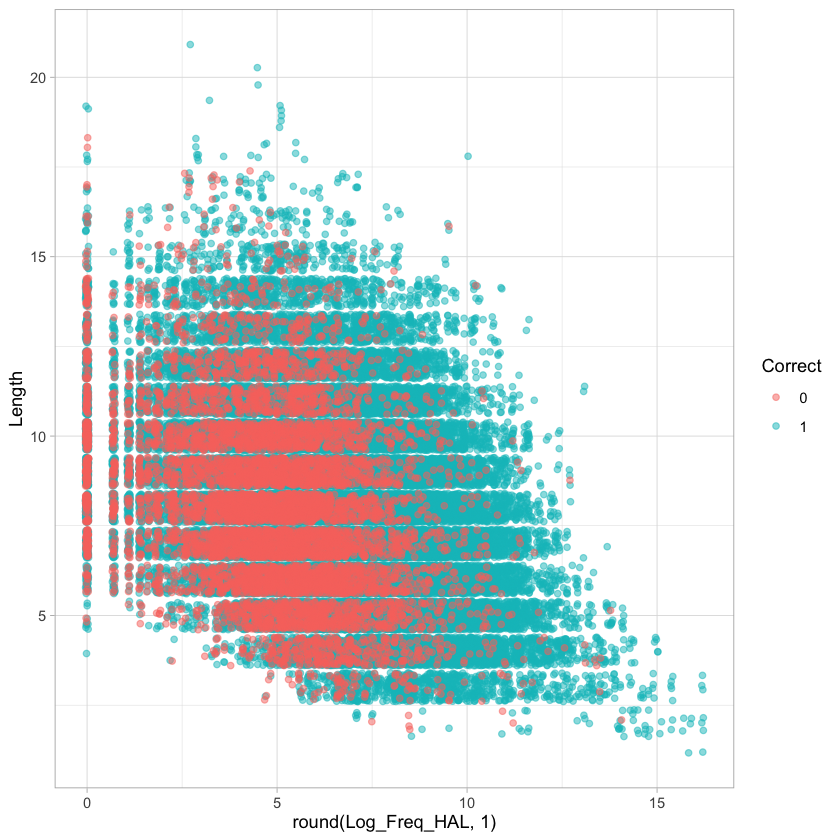

In [30]:
require(tidyverse) # Load the tidyverse package, if you haven't yet
joined_data$Correct <- as.factor(joined_data$Correct) # so that R knows that Correct is categorical, not numeric.

# plot the Correct / Incorrect clusters
ggplot(joined_data,aes(x=round(Log_Freq_HAL,1),y=Length,col=Correct)) + geom_point(position="jitter",alpha=0.5) + theme_light()


What do you observe about the "Correct" and "Incorrect" clusters?

> More infrequent words are responded to incorrectly more often, while more frequent words are responded to correctly.
> Interestingly, it seems like longer common words are responded to correctly than shorter common words (although I'm not sure if that is just an artifact of graphing)

---
## 3. Logistic Regression: Fitting the model (3 points)

Fit a logistic regression model to the data using `Length`, `Log_Freq_HAL`, and their interaction to predict `Correct`. Use `glm()` to fit the model, and look at its output using `summary()`.

In [32]:
# Run the GLM
glm.fit=glm(Correct~Length*Log_Freq_HAL, data=joined_data, family=binomial) # logistic regression 

# Summarize
summary(glm.fit)


Call:
glm(formula = Correct ~ Length * Log_Freq_HAL, family = binomial, 
    data = joined_data)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -0.939996   0.115623  -8.130 4.30e-16 ***
Length               0.151266   0.012789  11.828  < 2e-16 ***
Log_Freq_HAL         0.394772   0.018762  21.041  < 2e-16 ***
Length:Log_Freq_HAL -0.010558   0.002202  -4.795 1.63e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 49809  on 70588  degrees of freedom
Residual deviance: 46563  on 70585  degrees of freedom
AIC: 46571

Number of Fisher Scoring iterations: 5


What can you conclude from this output? (a brief gist is fine)

> Based on the p-values, I conclude that length and log frequency separately, as well as their interaction, significantly predict whether the word will be responded to correctly or not. 

---
## 4. Interpreting predictions from the model (4 points)

Finally, look at how well this logistic regression model does at predicting correctness. Use `predict()` and a threshold of 0.5 to generate predicted `Correct` values for each trial, then output a confusion matrix and overall accuracy for these predictions.

*Hint: see the Classifiers tutorial.*

In [47]:
# See how well the model captured the training set
glm_prob_df = data.frame(predict(glm.fit, type = "response"))
colnames(glm_prob_df) = c('predicted_prob')

num_observations = nrow(glm_prob_df)
#glm_prob_df$index = seq(1, num_observations) #get the observation number for plotting; ggplot does not infer this

threshold = 0.50 #binarizing threshold 
glm_prob_df$predicted_binary=rep("0",num_observations)
glm_prob_df$predicted_binary[glm_prob_df$predicted_prob>threshold]="1" #find the rows that have prob > threshold and cast as 'correct'

# Now let's look at the prediction accuracy
confusion_df = data.frame(glm_prob_df$predicted_binary, joined_data$Correct)
colnames(confusion_df) = c('predicted', 'actual')

table(confusion_df)

print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))

         actual
predicted     0     1
        0    13    44
        1  7966 62566

[1] "Accuracy: 0.886526229299183"


Did the model do well at predicting lexical decision correctness? Why or why not?

> If I did the "Incorrect-Correct" assignment correctly, then it looks like the model did relatively well, with an accuracy of ~%89. While the model made some false predictions, the correct predictions seem to outnumber them -- at least in the case of correct responses. The model seems to have made many "false positives", predicting that incorrect answers would be correct. But overall, the accuracy still seems relatively high. 

**DUE:** 11:59pm EST, March 3, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
> I used chatGPT to clarify left_join syntax from Question#1. Here was my original prompt: I am trying to add two columns from df2 to df1 in r using left_join. But I keep getting the error that "! Join columns in x must be present in the data." Here is my code: joined_data <- left_join(resps, items, by = c("Length", "Log_Freq_Hal"))